In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

from obspy import read

MSEED_PATH = "/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/event_example.mseed"

def main():
    st = read(MSEED_PATH)

    print("=== Stream summary ===")
    print(st)

    # Earliest start time across all traces (useful as "file start time")
    t0 = min(tr.stats.starttime for tr in st)
    t1 = max(tr.stats.endtime for tr in st)
    print("\n=== Time coverage (all traces) ===")
    print(f"Earliest start: {t0} (UTC)")
    print(f"Latest end    : {t1} (UTC)")
    print(f"Duration      : {t1 - t0:.3f} s")

    print("\n=== Per-trace headers ===")
    for i, tr in enumerate(st, 1):
        stats = tr.stats
        print(f"\nTrace #{i}: {tr.id}")  # NET.STA.LOC.CHA
        print(f"  Network      : {stats.network}")
        print(f"  Station      : {stats.station}")
        print(f"  Location code: {stats.location!r}")
        print(f"  Channel      : {stats.channel}")
        print(f"  Start time   : {stats.starttime} (UTC)")
        print(f"  End time     : {stats.endtime} (UTC)")
        print(f"  Sampling rate: {stats.sampling_rate} Hz")
        print(f"  Npts         : {stats.npts}")

if __name__ == "__main__":
    main()

=== Stream summary ===
1 Trace(s) in Stream:
XA.S15..SHZ | 1976-03-06T10:03:00.015107Z - 1976-03-06T10:31:59.996239Z | 53.0 Hz, 92220 samples

=== Time coverage (all traces) ===
Earliest start: 1976-03-06T10:03:00.015107Z (UTC)
Latest end    : 1976-03-06T10:31:59.996239Z (UTC)
Duration      : 1739.981 s

=== Per-trace headers ===

Trace #1: XA.S15..SHZ
  Network      : XA
  Station      : S15
  Location code: ''
  Channel      : SHZ
  Start time   : 1976-03-06T10:03:00.015107Z (UTC)
  End time     : 1976-03-06T10:31:59.996239Z (UTC)
  Sampling rate: 53.0 Hz
  Npts         : 92220


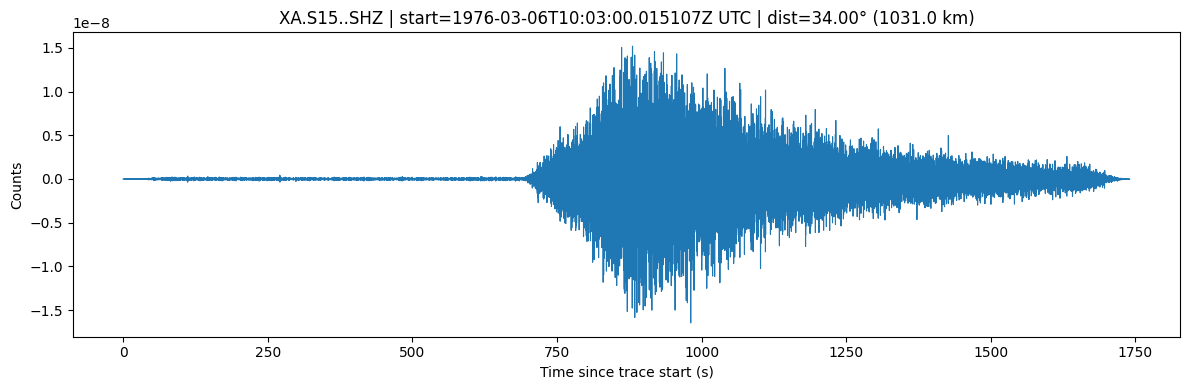

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from datetime import datetime

# --- your inputs ---
MSEED_PATH = "/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/event_example.mseed"
# OUT_DIR = "/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/Shallow/S15/SP/19760306T101600/SHZ/"
DIST_DEG = 34.0
MOON_RADIUS_KM = 1737.4
# -------------------

def deg_to_km(deg, radius_km=MOON_RADIUS_KM):
    return radius_km * (np.pi/180.0) * float(deg)

# make sure output dir exists
# os.makedirs(OUT_DIR, exist_ok=True)

# read waveform file (do NOT change directory)
st = read(MSEED_PATH)

# merge if split into segments
try:
    st.merge(method=1, fill_value="interpolate")
except Exception:
    pass

# pick the longest trace
tr = max(st, key=lambda t: t.stats.npts).copy()

# optional light preprocessing (keep if you want; note this changes what you save)
#tr.detrend("demean")
#tr.detrend("linear")
#tr.taper(max_percentage=0.02, type="cosine")

# distance
dist_km = deg_to_km(DIST_DEG)

# time axis for plotting (seconds)
sr = float(tr.stats.sampling_rate)
t = np.arange(tr.stats.npts) / sr
y = tr.data.astype(float)

# outputs (ONLY under OUT_DIR)
# out_png = os.path.join(OUT_DIR, "seismogram_dist.png")
# out_txt = os.path.join(OUT_DIR, "seismogram_dist.txt")

# plot + save
plt.figure(figsize=(12, 4))
plt.plot(t, y, linewidth=0.8)
plt.xlabel("Time since trace start (s)")
plt.ylabel("Counts")
plt.title(f"{tr.id} | start={tr.stats.starttime} UTC | dist={DIST_DEG:.2f}° ({dist_km:.1f} km)")
plt.tight_layout()
# plt.savefig(out_png, dpi=200)
plt.show()

# ---- WRITE CORRECT TXT (reference-compatible time series) ----
# Format expected by your reference loader:
#   header: "Time Amplitude"
#   each line: "<ISO8601 time> <amplitude>"
t0 = tr.stats.starttime
times = [t0 + (i / sr) for i in range(tr.stats.npts)]

# with open(out_txt, "w", encoding="utf-8") as f:
#     f.write("Time Amplitude\n")
#     for tt, amp in zip(times, y):
#         f.write(f"{tt.isoformat()} {amp:.6e}\n")

# print("[OK] wrote", out_png)
# print("[OK] wrote (reference-compatible time series)", out_txt)


In [30]:
import os
import numpy as np
import pandas as pd
from obspy import UTCDateTime, read
from scipy.signal import butter, filtfilt

# ----------------- user config -----------------
MSEED_PATH = "/Users/yanyuzhang/Documents/Python/event_example.mseed"

SEISMO_DIR = "/Users/yanyuzhang/Documents/Python/Shallow/S15/SP/19760306T101600/SHZ/"
DIST_TXT   = os.path.join(SEISMO_DIR, "seismogram_dist.txt")

# Fixed band you asked
LOWCUT = 2.5
HIGHCUT = 3.5

# Reference constants
FS_SP = 53.0  # FS_BY_SENSOR["SP"]
ORDER = 4
WIN_SECONDS = 15  # smoothing_window_seconds("SP") in your ref
NOISE_BASE_DIR = "/Users/yanyuzhang/Documents/Python/noise_convert/VEL"
NOISE_CSV = os.path.join(NOISE_BASE_DIR, "S15_SHZ.csv")  # same naming as ref: f"{station}_{channel}.csv"

OUT_TXT = os.path.join(SEISMO_DIR, "seismogram_3.0_100s.txt")
# ------------------------------------------------

os.makedirs(SEISMO_DIR, exist_ok=True)

def load_seismogram_txt(path: str):
    """Same as your reference: header then 'ISOTime amplitude' lines."""
    times, data = [], []
    with open(path, "r", encoding="utf-8") as fh:
        fh.readline()  # discard header
        for line in fh:
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                times.append(UTCDateTime(parts[0]))
                data.append(float(parts[1]))
            except Exception:
                continue
    if len(data) < 2:
        raise RuntimeError(f"Not enough samples in {path}")
    return np.asarray(times, dtype=object), np.asarray(data, dtype=np.float64)

def seconds_since_start(times):
    t0 = times[0]
    return np.array([t - t0 for t in times], dtype=np.float64)

def butter_bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyquist = 0.5 * fs
    if lowcut <= 0 or highcut >= nyquist:
        raise ValueError(f"Band [{lowcut}, {highcut}] outside Nyquist={nyquist}")
    wn = [lowcut / nyquist, highcut / nyquist]
    b, a = butter(order, wn, btype="bandpass")
    return filtfilt(b, a, data)

def rolling_average_time(times_sec, values, window):
    """Same logic as your reference (rolling mean over samples)."""
    if len(times_sec) < window or window < 1:
        return None, None
    time_rolled, val_rolled = [], []
    for i in range(len(values) - window + 1):
        twindow = times_sec[i : i + window]
        vwindow = values[i : i + window]
        time_rolled.append(np.mean(twindow))
        val_rolled.append(np.mean(vwindow))
    return np.array(time_rolled, dtype=np.float64), np.array(val_rolled, dtype=np.float64)

def write_filtered_trace(path, times_utc, arr):
    """Same as your reference: 'Time Amplitude' header."""
    with open(path, "w", encoding="utf-8") as fh:
        fh.write("Time Amplitude\n")
        for t, amp in zip(times_utc, arr):
            fh.write(f"{t.isoformat()} {amp:.6e}\n")

def compute_band_limited_noise_power(noise_csv_path, low, high):
    """Same as your reference: integrate one-sided PSD over band."""
    df = pd.read_csv(noise_csv_path)
    freq = df["frequency"].to_numpy()
    psd = df["psd_vel"].to_numpy()  # keep DU/vel convention consistent with your ref
    mask = (freq >= 0) & (freq >= low) & (freq <= high)
    if not np.any(mask):
        raise ValueError("No PSD data within the specified band")
    power = np.trapz(psd[mask], freq[mask])
    if power <= 0:
        raise ValueError("Computed power is non-positive")
    return float(power)

def dist_txt_looks_like_timeseries(path):
    """Quick check: can we parse at least a couple of Time/Amplitude lines?"""
    try:
        with open(path, "r", encoding="utf-8") as fh:
            _ = fh.readline()
            good = 0
            for _ in range(20):
                line = fh.readline()
                if not line:
                    break
                parts = line.split()
                if len(parts) < 2:
                    continue
                try:
                    UTCDateTime(parts[0])
                    float(parts[1])
                    good += 1
                except Exception:
                    continue
            return good >= 2
    except Exception:
        return False

# -------------------------------------------------------------------
# 0) Ensure seismogram_dist.txt is a proper Time/Amplitude time series.
#    If not, rebuild it from MSEED_PATH into the SAME file (no chdir).
# -------------------------------------------------------------------
if (not os.path.exists(DIST_TXT)) or (not dist_txt_looks_like_timeseries(DIST_TXT)):
    st = read(MSEED_PATH)
    try:
        st.merge(method=1, fill_value="interpolate")
    except Exception:
        pass
    tr = max(st, key=lambda t: t.stats.npts).copy()

    # Write Time/Amplitude seismogram_dist.txt (raw trace, ISO timestamps) — consistent with reference txt format
    times = [tr.stats.starttime + (i / tr.stats.sampling_rate) for i in range(tr.stats.npts)]
    write_filtered_trace(DIST_TXT, times, tr.data.astype(np.float64))
    print("[INFO] Rebuilt seismogram_dist.txt as Time/Amplitude time series from:", MSEED_PATH)

# -------------------------------------------------------------------
# 1) Load dist txt (now guaranteed Time/Amplitude)
# 2) Bandpass (order 4, filtfilt)
# 3) Square
# 4) 100s rolling average (SP)
# 5) Noise normalization (integrated PSD power)
# 6) Write output
# -------------------------------------------------------------------
if not os.path.exists(NOISE_CSV):
    raise FileNotFoundError(f"Missing noise PSD CSV required by reference processing: {NOISE_CSV}")

times, data = load_seismogram_txt(DIST_TXT)
time_sec = seconds_since_start(times)

filtered = butter_bandpass_filter(data, FS_SP, LOWCUT, HIGHCUT, order=ORDER)
filtered = filtered ** 2

window_samples = max(1, int(round(WIN_SECONDS * FS_SP)))
t_sm, y_sm = rolling_average_time(time_sec, filtered, window_samples)
if t_sm is None:
    raise RuntimeError(
        f"Not enough samples for {WIN_SECONDS}s rolling average: "
        f"need {window_samples}, have {len(data)}."
    )

noise_power = compute_band_limited_noise_power(NOISE_CSV, LOWCUT, HIGHCUT)
y_norm = y_sm / noise_power

times_sm = np.array([times[0] + t for t in t_sm], dtype=object)
write_filtered_trace(OUT_TXT, times_sm, y_norm)

print("[OK] Input :", DIST_TXT)
print("[OK] Output:", OUT_TXT)
print(f"[INFO] fs={FS_SP} Hz | band={LOWCUT}-{HIGHCUT} Hz | order={ORDER} | window={WIN_SECONDS}s ({window_samples} samples) | noise={NOISE_CSV}")


[OK] Input : /Users/yanyuzhang/Documents/Python/Shallow/S15/SP/19760306T101600/SHZ/seismogram_dist.txt
[OK] Output: /Users/yanyuzhang/Documents/Python/Shallow/S15/SP/19760306T101600/SHZ/seismogram_3.0_100s.txt
[INFO] fs=53.0 Hz | band=2.5-3.5 Hz | order=4 | window=15s (795 samples) | noise=/Users/yanyuzhang/Documents/Python/noise_convert/VEL/S15_SHZ.csv


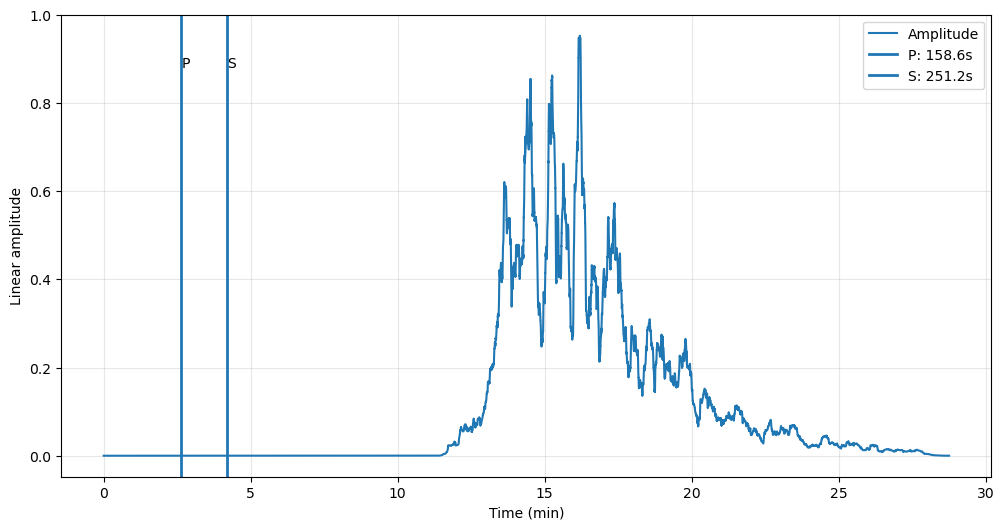

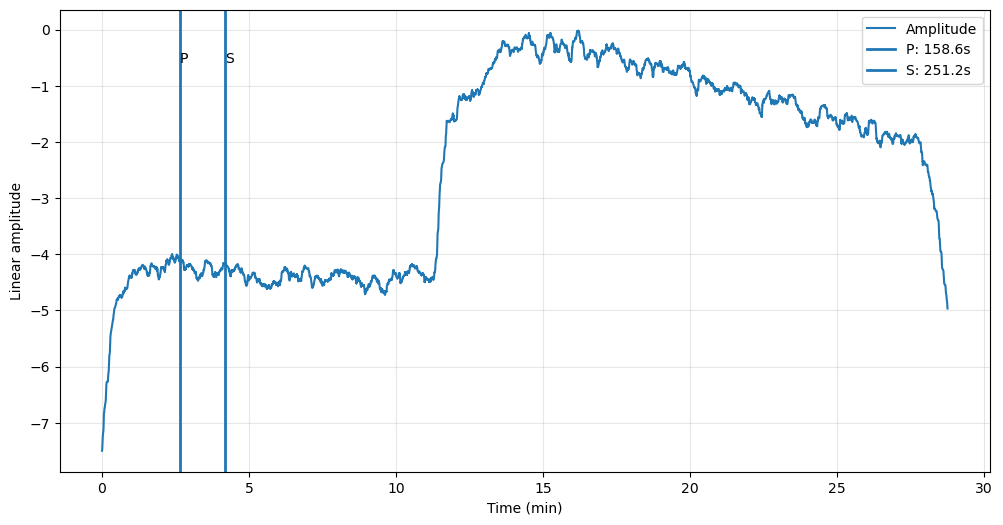

P_START_UTC = 1976-03-06T10:15:00.600000Z
S_START_UTC = 1976-03-06T10:16:33.200000Z
P_START_SEC = 158.6
S_START_SEC = 251.2


In [39]:
from typing import Dict, List, Optional, Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt
from obspy import UTCDateTime

def load_seismogram_txt(path: str) -> Tuple[np.ndarray, np.ndarray]:
    times: List[UTCDateTime] = []
    data: List[float] = []
    with open(path, "r", encoding="utf-8") as fh:
        fh.readline()  # discard header
        for line in fh:
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                times.append(UTCDateTime(parts[0]))
                data.append(float(parts[1]))
            except Exception:
                continue
    if len(data) < 2:
        raise RuntimeError(f"Not enough samples in {path}")
    return np.asarray(times, dtype=object), np.asarray(data, dtype=np.float64)

def _to_log10_ratio(x: np.ndarray, floor: float = 1e-12) -> np.ndarray:
    pos = x[x > 0]
    f = floor if pos.size == 0 else min(floor, max(1e-300, 0.1 * np.min(pos)))
    return np.log10(np.clip(x, f, None))

def seconds_since_start(times: Sequence[UTCDateTime]) -> np.ndarray:
    t0 = times[0]
    return np.array([t - t0 for t in times], dtype=np.float64)

# ---- load ----
path = "/Users/yanyuzhang/Documents/Python/Shallow/S15/SP/19760306T101600/SHZ/seismogram_3.0_100s.txt"
time, data = load_seismogram_txt(path)
t = seconds_since_start(time)

# (optional) log envelope if you need later
env = _to_log10_ratio(data)

# ---- P/S picks (given) ----
EVENT_START = UTCDateTime("1976-03-06T10:12:22")
P_OFFSET_S = 158.6
S_OFFSET_S = 251.2

# Save for following cells (absolute UTC + relative seconds)
P_START_UTC = EVENT_START + P_OFFSET_S
S_START_UTC = EVENT_START + S_OFFSET_S
P_START_SEC = float(P_OFFSET_S)
S_START_SEC = float(S_OFFSET_S)

# ---- plot ----
plt.figure(figsize=(12, 6))
plt.plot(t / 60.0, data, label="Amplitude")

# vertical markers (minutes)
plt.axvline(P_START_SEC / 60.0, linewidth=2, label=f"P: {P_OFFSET_S:.1f}s")
plt.axvline(S_START_SEC / 60.0, linewidth=2, label=f"S: {S_OFFSET_S:.1f}s")

# annotate (keep inside axes)
ymax = np.nanmax(data)
ymin = np.nanmin(data)
yr = ymax - ymin if np.isfinite(ymax) and np.isfinite(ymin) else 1.0
y_text = ymax - 0.05 * yr

plt.text(P_START_SEC / 60.0, y_text, "P", ha="left", va="top")
plt.text(S_START_SEC / 60.0, y_text, "S", ha="left", va="top")

#plt.xlim(9, 30)
plt.ylabel("Linear amplitude")
plt.xlabel("Time (min)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(t / 60.0, env, label="Amplitude")

# vertical markers (minutes)
plt.axvline(P_START_SEC / 60.0, linewidth=2, label=f"P: {P_OFFSET_S:.1f}s")
plt.axvline(S_START_SEC / 60.0, linewidth=2, label=f"S: {S_OFFSET_S:.1f}s")

# annotate (keep inside axes)
ymax = np.nanmax(env)
ymin = np.nanmin(env)
yr = ymax - ymin if np.isfinite(ymax) and np.isfinite(ymin) else 1.0
y_text = ymax - 0.05 * yr

plt.text(P_START_SEC / 60.0, y_text, "P", ha="left", va="top")
plt.text(S_START_SEC / 60.0, y_text, "S", ha="left", va="top")

#plt.xlim(9, 30)
plt.ylabel("Linear amplitude")
plt.xlabel("Time (min)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print("P_START_UTC =", P_START_UTC)
print("S_START_UTC =", S_START_UTC)
print("P_START_SEC =", P_START_SEC)
print("S_START_SEC =", S_START_SEC)

seeing discripency, P and S start time use mannual pick results, P_start = 11.29min, S_start=12.82min

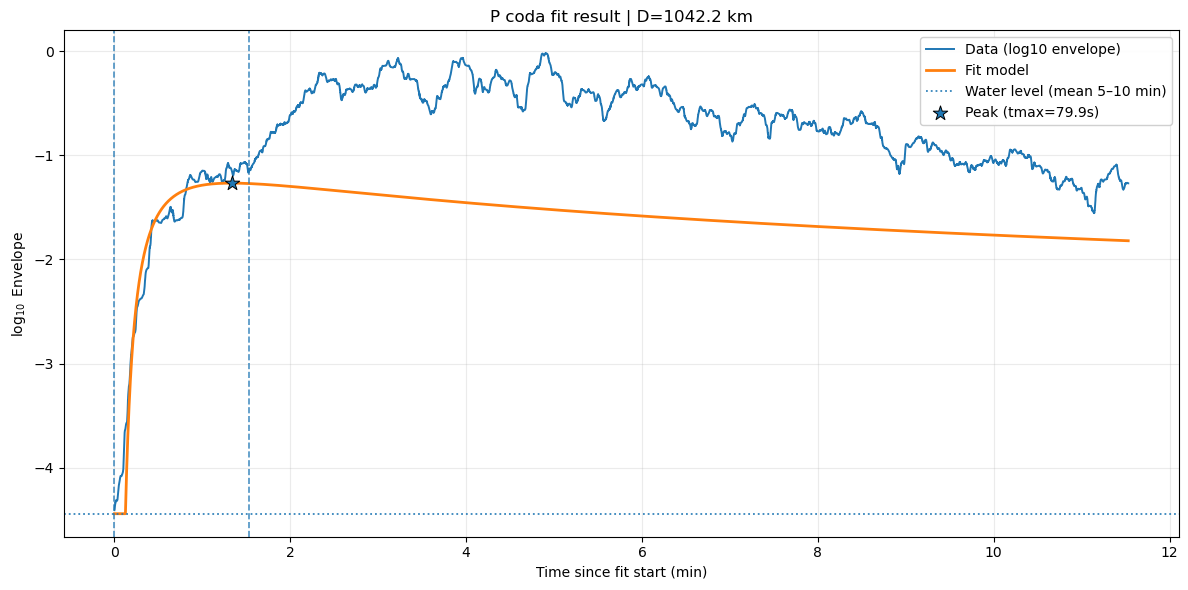

P fitting results
log10_A2: 0.15126629718532159
q0: 6.962613751468628
alpha: 0.12064906955092317
sigma (km): 335.7283301392909


In [55]:
# --- NEW CELL: single-event coda fit on a chosen window (no perturbation/uncertainty) ---

import numpy as np
import matplotlib.pyplot as plt
from obspy import UTCDateTime
from scipy.optimize import least_squares

# ------------------ easy-to-edit knobs ------------------
FNAME = "/Users/yanyuzhang/Documents/Python/Shallow/S15/SP/19760306T101600/SHZ/seismogram_3.0_100s.txt"

# Fit window (minutes since file start)
FIT_START_MIN = 11.29
FIT_END_MIN   = 12.82

# Water level window (minutes since file start)
WATER_LEVEL_START_MIN = 5.0
WATER_LEVEL_END_MIN   = 10.0

# Plot extra time AFTER the fit window (minutes)
PLOT_EXTRA_AFTER_FIT_MIN = 10.0

# Distance for THIS station/event (km) — you must set this
D_KM = 1042.18  # <-- CHANGE ME

# Model/fit constants
T_EPS_SEC = 1.0
P_LOWER = np.array([-6.0, 0.01, 0.01, 0.1], dtype=float)   # [log10_A2, q0, alpha, sigma_km]
P_UPPER = np.array([15.0, 10.0, 5.0, 500.0], dtype=float)
P0      = np.array([5.0, 5.0, 1.0, 100.0], dtype=float)
# --------------------------------------------------------


# --------- helpers (same style as your program) ----------
def load_seismogram_txt(path: str):
    times, data = [], []
    with open(path, "r", encoding="utf-8") as fh:
        fh.readline()  # header
        for line in fh:
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                times.append(UTCDateTime(parts[0]))
                data.append(float(parts[1]))
            except Exception:
                continue
    if len(data) < 2:
        raise RuntimeError(f"Not enough samples in {path}")
    return np.asarray(times, dtype=object), np.asarray(data, dtype=np.float64)

def seconds_since_start(times):
    t0 = times[0]
    return np.array([t - t0 for t in times], dtype=np.float64)

def _to_log10_ratio(x: np.ndarray, floor: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    pos = x[x > 0]
    if pos.size == 0:
        f = floor
    else:
        f = min(floor, max(1e-300, 0.1 * np.min(pos)))
    return np.log10(np.clip(x, f, None))

def coda_log10_model(t_rel, log10_A2, q0, alpha, sigma_km, D_km, water_level_fit):
    t_rel = np.asarray(t_rel, dtype=np.float64)
    t_rel = np.clip(t_rel, T_EPS_SEC, None)

    A2 = 10.0 ** log10_A2
    q = 1.0 - 10.0 ** (-q0)
    q = np.clip(q, 1e-6, 0.999999)

    sigma_km = max(1e-3, float(sigma_km))
    S = (float(D_km) / sigma_km) ** 2

    inv_alpha_t = 1.0 / (float(alpha) * t_rel)
    exponent = -inv_alpha_t * S
    lnq = np.log(q)
    power_term = np.exp(float(alpha) * t_rel * lnq)

    e_t = A2 * power_term * inv_alpha_t * np.exp(exponent)
    e_t_clipped = np.clip(e_t, float(water_level_fit), None)
    return np.log10(e_t_clipped)

def fit_coda_shape(t_rel, log_env, D_km, water_level_fit):
    t_rel = np.asarray(t_rel, dtype=np.float64)
    log_env = np.asarray(log_env, dtype=np.float64)

    m = np.isfinite(log_env)
    if m.sum() < 10:
        return None, None

    t_fit = t_rel[m]
    y_fit = log_env[m]

    def residuals(p):
        y_model = coda_log10_model(t_fit, p[0], p[1], p[2], p[3], D_km, water_level_fit)
        return y_model - y_fit

    r = least_squares(
        residuals,
        P0,
        bounds=(P_LOWER, P_UPPER),
        method="trf",
        max_nfev=2000,
    )
    if not r.success:
        return None, None

    info = {
        "result": r,
        "t_fit": t_fit,
        "y_fit": y_fit,
        "y_model_best": coda_log10_model(t_fit, r.x[0], r.x[1], r.x[2], r.x[3], D_km, water_level_fit),
        "residuals": residuals(r.x),
    }
    return r.x, info

def compute_e_max_and_tmax(log10_A2, q0, alpha, sigma_km, D_km):
    A2 = 10.0 ** log10_A2
    q = 1.0 - 10.0 ** (-q0)
    q = np.clip(q, 1e-6, 0.999999)
    lnq = np.log(q)

    sigma_km = max(1e-3, float(sigma_km))
    S = (float(D_km) / sigma_km) ** 2

    radicand = 1.0 - 4.0 * lnq * S
    if radicand <= 0.0:
        radicand = 1e-6

    t_max = (1.0 / float(alpha)) * (2.0 * S / (1.0 + np.sqrt(radicand)))

    inv_alpha_t = 1.0 / (float(alpha) * t_max)
    exponent = -inv_alpha_t * S
    power_term = np.exp(float(alpha) * t_max * lnq)

    e_max = A2 * power_term * inv_alpha_t * np.exp(exponent)
    return float(t_max), float(e_max)
# --------------------------------------------------------


# --------- load + build envelope log10 ----------
times, data = load_seismogram_txt(FNAME)
t_sec = seconds_since_start(times)
env_log = _to_log10_ratio(np.abs(data))

# --------- water level from 5–10 min ----------
wl0 = WATER_LEVEL_START_MIN * 60.0
wl1 = WATER_LEVEL_END_MIN * 60.0
m_wl = (t_sec >= wl0) & (t_sec <= wl1) & np.isfinite(env_log)
if m_wl.sum() < 10:
    raise RuntimeError("Too few samples in water-level window. Adjust WATER_LEVEL_*_MIN.")
noise_log = float(np.mean(env_log[m_wl]))
water_level_fit = float(10.0 ** noise_log)

# --------- fit window 11.29–12.82 min ----------
fit0 = FIT_START_MIN * 60.0
fit1 = FIT_END_MIN   * 60.0
m_fit = (t_sec >= fit0) & (t_sec <= fit1) & np.isfinite(env_log)
if m_fit.sum() < 10:
    raise RuntimeError("Too few samples in fit window. Adjust FIT_*_MIN.")

t_win = t_sec[m_fit]
y_win = env_log[m_fit]
t_rel = t_win - fit0  # relative to fit start, like your program (t0_fit = t_start_S_manual)

# --------- fit ----------
params, info = fit_coda_shape(t_rel, y_win, D_KM, water_level_fit)
if params is None:
    raise RuntimeError("Fit failed (least_squares did not converge).")

log10_A2, q0, alpha, sigma_km = params
t_max_rel, e_max = compute_e_max_and_tmax(log10_A2, q0, alpha, sigma_km, D_KM)
log10_e_max = float(np.log10(e_max))

# --------- plot range: fit window + 10 min after ----------
plot_end_sec = fit1 + PLOT_EXTRA_AFTER_FIT_MIN * 60.0
m_plot = (t_sec >= fit0) & (t_sec <= plot_end_sec) & np.isfinite(env_log)

t_plot = t_sec[m_plot]
y_plot = env_log[m_plot]
t_rel_plot = t_plot - fit0

y_model_plot = coda_log10_model(
    t_rel_plot, log10_A2, q0, alpha, sigma_km, D_KM, water_level_fit
)

# peak time (absolute, in seconds since file start)
t_peak_abs_sec = fit0 + t_max_rel
t_peak_abs_min = t_peak_abs_sec / 60.0

# --------- figure ----------
plt.figure(figsize=(12, 6))
plt.plot((t_plot - fit0) / 60.0, y_plot, linewidth=1.4, label="Data (log10 envelope)")
plt.plot((t_plot - fit0) / 60.0, y_model_plot, linewidth=2.0, label="Fit model")

# show fit window bounds (relative to fit start)
plt.axvline(0.0, linestyle="--", linewidth=1.2, alpha=0.8)
plt.axvline((fit1 - fit0) / 60.0, linestyle="--", linewidth=1.2, alpha=0.8)

# water level line (log10)
plt.axhline(noise_log, linestyle=":", linewidth=1.3, alpha=0.9, label="Water level (mean 5–10 min)")

# mark peak (t_max)
plt.scatter([t_max_rel / 60.0], [log10_e_max], s=120, marker="*", edgecolors="k", linewidths=0.7, zorder=5,
            label=f"Peak (tmax={t_max_rel:.1f}s)")

plt.xlabel("Time since fit start (min)")
plt.ylabel(r"$\log_{10}$ Envelope")
plt.title(
    f"P coda fit result | "
    f"D={D_KM:.1f} km"
)
plt.grid(True, alpha=0.25)
plt.legend(framealpha=0.92)
plt.tight_layout()
plt.show()

# --------- save key variables for following cells ----------
FIT_START_SEC = float(fit0)
FIT_END_SEC   = float(fit1)
WATER_LEVEL_LOG10 = float(noise_log)
WATER_LEVEL_LINEAR = float(water_level_fit)

CODA_PARAMS = {
    "log10_A2": float(log10_A2),
    "q0": float(q0),
    "alpha": float(alpha),
    "sigma_km": float(sigma_km),
    "D_km": float(D_KM),
}
TMAX_REL_SEC = float(t_max_rel)
TPEAK_ABS_SEC = float(t_peak_abs_sec)
LOG10_E_MAX = float(log10_e_max)

print("P fitting results")
print(f'log10_A2: {float(log10_A2)}')
print(f'q0: {float(q0)}')
print(f'alpha: {float(alpha)}')
print(f'sigma (km): {float(sigma_km)}')

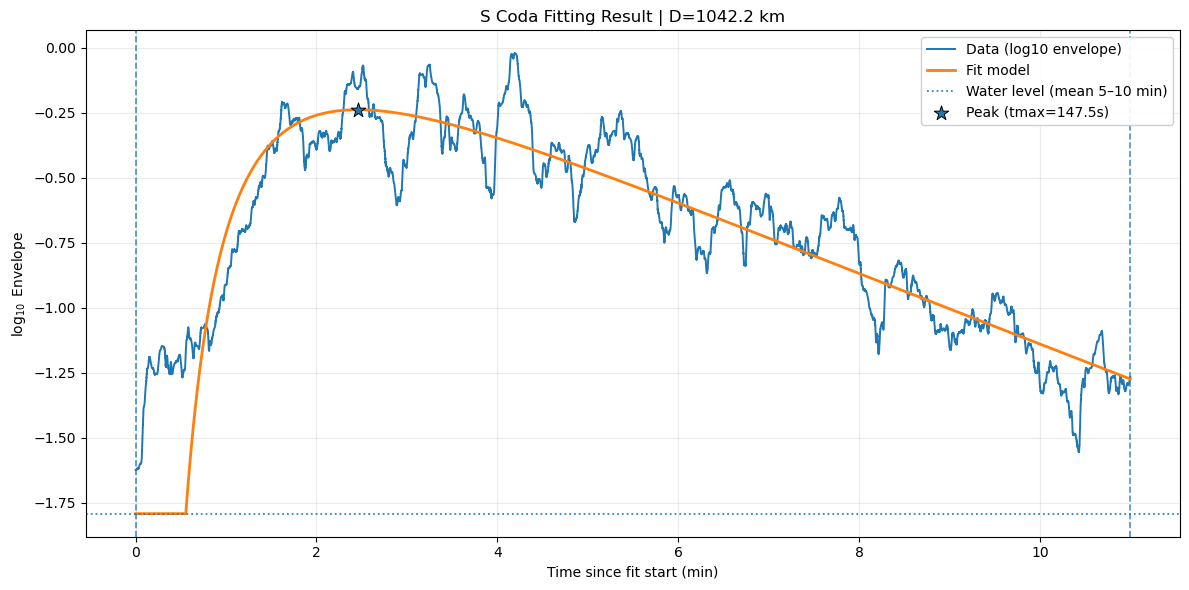

S fitting results
log10_A2: 3.046034472690031
q0: 2.5248017313619147
alpha: 1.3975905312224361
sigma (km): 57.101595720365694


In [54]:
# --- NEW CELL: single-event coda fit on a chosen window (no perturbation/uncertainty) ---

import numpy as np
import matplotlib.pyplot as plt
from obspy import UTCDateTime
from scipy.optimize import least_squares

# ------------------ easy-to-edit knobs ------------------
FNAME = "/Users/yanyuzhang/Documents/Python/Shallow/S15/SP/19760306T101600/SHZ/seismogram_3.0_100s.txt"

# Fit window (minutes since file start)
FIT_START_MIN = 12.00
FIT_END_MIN   = 23.00

# Water level window (minutes since file start)
WATER_LEVEL_START_MIN = 11.29
WATER_LEVEL_END_MIN   = 12.82

# Plot extra time AFTER the fit window (minutes)
PLOT_EXTRA_AFTER_FIT_MIN = 0.0

# Distance for THIS station/event (km) — you must set this
D_KM = 1042.18  # <-- CHANGE ME

# Model/fit constants
T_EPS_SEC = 1.0
P_LOWER = np.array([-6.0, 0.01, 0.01, 0.1], dtype=float)   # [log10_A2, q0, alpha, sigma_km]
P_UPPER = np.array([15.0, 10.0, 5.0, 500.0], dtype=float)
P0      = np.array([5.0, 5.0, 1.0, 100.0], dtype=float)
# --------------------------------------------------------


# --------- helpers (same style as your program) ----------
def load_seismogram_txt(path: str):
    times, data = [], []
    with open(path, "r", encoding="utf-8") as fh:
        fh.readline()  # header
        for line in fh:
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                times.append(UTCDateTime(parts[0]))
                data.append(float(parts[1]))
            except Exception:
                continue
    if len(data) < 2:
        raise RuntimeError(f"Not enough samples in {path}")
    return np.asarray(times, dtype=object), np.asarray(data, dtype=np.float64)

def seconds_since_start(times):
    t0 = times[0]
    return np.array([t - t0 for t in times], dtype=np.float64)

def _to_log10_ratio(x: np.ndarray, floor: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    pos = x[x > 0]
    if pos.size == 0:
        f = floor
    else:
        f = min(floor, max(1e-300, 0.1 * np.min(pos)))
    return np.log10(np.clip(x, f, None))

def coda_log10_model(t_rel, log10_A2, q0, alpha, sigma_km, D_km, water_level_fit):
    t_rel = np.asarray(t_rel, dtype=np.float64)
    t_rel = np.clip(t_rel, T_EPS_SEC, None)

    A2 = 10.0 ** log10_A2
    q = 1.0 - 10.0 ** (-q0)
    q = np.clip(q, 1e-6, 0.999999)

    sigma_km = max(1e-3, float(sigma_km))
    S = (float(D_km) / sigma_km) ** 2

    inv_alpha_t = 1.0 / (float(alpha) * t_rel)
    exponent = -inv_alpha_t * S
    lnq = np.log(q)
    power_term = np.exp(float(alpha) * t_rel * lnq)

    e_t = A2 * power_term * inv_alpha_t * np.exp(exponent)
    e_t_clipped = np.clip(e_t, float(water_level_fit), None)
    return np.log10(e_t_clipped)

def fit_coda_shape(t_rel, log_env, D_km, water_level_fit):
    t_rel = np.asarray(t_rel, dtype=np.float64)
    log_env = np.asarray(log_env, dtype=np.float64)

    m = np.isfinite(log_env)
    if m.sum() < 10:
        return None, None

    t_fit = t_rel[m]
    y_fit = log_env[m]

    def residuals(p):
        y_model = coda_log10_model(t_fit, p[0], p[1], p[2], p[3], D_km, water_level_fit)
        return y_model - y_fit

    r = least_squares(
        residuals,
        P0,
        bounds=(P_LOWER, P_UPPER),
        method="trf",
        max_nfev=2000,
    )
    if not r.success:
        return None, None

    info = {
        "result": r,
        "t_fit": t_fit,
        "y_fit": y_fit,
        "y_model_best": coda_log10_model(t_fit, r.x[0], r.x[1], r.x[2], r.x[3], D_km, water_level_fit),
        "residuals": residuals(r.x),
    }
    return r.x, info

def compute_e_max_and_tmax(log10_A2, q0, alpha, sigma_km, D_km):
    A2 = 10.0 ** log10_A2
    q = 1.0 - 10.0 ** (-q0)
    q = np.clip(q, 1e-6, 0.999999)
    lnq = np.log(q)

    sigma_km = max(1e-3, float(sigma_km))
    S = (float(D_km) / sigma_km) ** 2

    radicand = 1.0 - 4.0 * lnq * S
    if radicand <= 0.0:
        radicand = 1e-6

    t_max = (1.0 / float(alpha)) * (2.0 * S / (1.0 + np.sqrt(radicand)))

    inv_alpha_t = 1.0 / (float(alpha) * t_max)
    exponent = -inv_alpha_t * S
    power_term = np.exp(float(alpha) * t_max * lnq)

    e_max = A2 * power_term * inv_alpha_t * np.exp(exponent)
    return float(t_max), float(e_max)
# --------------------------------------------------------


# --------- load + build envelope log10 ----------
times, data = load_seismogram_txt(FNAME)
t_sec = seconds_since_start(times)
env_log = _to_log10_ratio(np.abs(data))

# --------- water level from 5–10 min ----------
wl0 = WATER_LEVEL_START_MIN * 60.0
wl1 = WATER_LEVEL_END_MIN * 60.0
m_wl = (t_sec >= wl0) & (t_sec <= wl1) & np.isfinite(env_log)
if m_wl.sum() < 10:
    raise RuntimeError("Too few samples in water-level window. Adjust WATER_LEVEL_*_MIN.")
noise_log = float(np.mean(env_log[m_wl]))
water_level_fit = float(10.0 ** noise_log)

# --------- fit window 11.29–12.82 min ----------
fit0 = FIT_START_MIN * 60.0
fit1 = FIT_END_MIN   * 60.0
m_fit = (t_sec >= fit0) & (t_sec <= fit1) & np.isfinite(env_log)
if m_fit.sum() < 10:
    raise RuntimeError("Too few samples in fit window. Adjust FIT_*_MIN.")

t_win = t_sec[m_fit]
y_win = env_log[m_fit]
t_rel = t_win - fit0  # relative to fit start, like your program (t0_fit = t_start_S_manual)

# --------- fit ----------
params, info = fit_coda_shape(t_rel, y_win, D_KM, water_level_fit)
if params is None:
    raise RuntimeError("Fit failed (least_squares did not converge).")

log10_A2, q0, alpha, sigma_km = params
t_max_rel, e_max = compute_e_max_and_tmax(log10_A2, q0, alpha, sigma_km, D_KM)
log10_e_max = float(np.log10(e_max))

# --------- plot range: fit window + 10 min after ----------
plot_end_sec = fit1 + PLOT_EXTRA_AFTER_FIT_MIN * 60.0
m_plot = (t_sec >= fit0) & (t_sec <= plot_end_sec) & np.isfinite(env_log)

t_plot = t_sec[m_plot]
y_plot = env_log[m_plot]
t_rel_plot = t_plot - fit0

y_model_plot = coda_log10_model(
    t_rel_plot, log10_A2, q0, alpha, sigma_km, D_KM, water_level_fit
)

# peak time (absolute, in seconds since file start)
t_peak_abs_sec = fit0 + t_max_rel
t_peak_abs_min = t_peak_abs_sec / 60.0

# --------- figure ----------
plt.figure(figsize=(12, 6))
plt.plot((t_plot - fit0) / 60.0, y_plot, linewidth=1.4, label="Data (log10 envelope)")
plt.plot((t_plot - fit0) / 60.0, y_model_plot, linewidth=2.0, label="Fit model")

# show fit window bounds (relative to fit start)
plt.axvline(0.0, linestyle="--", linewidth=1.2, alpha=0.8)
plt.axvline((fit1 - fit0) / 60.0, linestyle="--", linewidth=1.2, alpha=0.8)

# water level line (log10)
plt.axhline(noise_log, linestyle=":", linewidth=1.3, alpha=0.9, label="Water level (mean 5–10 min)")

# mark peak (t_max)
plt.scatter([t_max_rel / 60.0], [log10_e_max], s=120, marker="*", edgecolors="k", linewidths=0.7, zorder=5,
            label=f"Peak (tmax={t_max_rel:.1f}s)")

plt.xlabel("Time since fit start (min)")
plt.ylabel(r"$\log_{10}$ Envelope")
plt.title(
    f"S Coda Fitting Result | "
    f"D={D_KM:.1f} km"
)
plt.grid(True, alpha=0.25)
plt.legend(framealpha=0.92)
plt.tight_layout()
plt.show()

# --------- save key variables for following cells ----------
FIT_START_SEC = float(fit0)
FIT_END_SEC   = float(fit1)
WATER_LEVEL_LOG10 = float(noise_log)
WATER_LEVEL_LINEAR = float(water_level_fit)

CODA_PARAMS = {
    "log10_A2": float(log10_A2),
    "q0": float(q0),
    "alpha": float(alpha),
    "sigma_km": float(sigma_km),
    "D_km": float(D_KM),
}
TMAX_REL_SEC = float(t_max_rel)
TPEAK_ABS_SEC = float(t_peak_abs_sec)
LOG10_E_MAX = float(log10_e_max)

print("S fitting results")
print(f'log10_A2: {float(log10_A2)}')
print(f'q0: {float(q0)}')
print(f'alpha: {float(alpha)}')
print(f'sigma (km): {float(sigma_km)}')